# Data Exploration: Final Merged Dataset with Genres

This notebook explores the cleaned dataset to check for:
- Outliers in numerical columns
- Genre breakdown and statistics
- Statistics about films
- Data quality for gross and revenue columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Dataset

In [20]:
# Load the dataset
df = pd.read_csv('data/cleaned/final_merged_dataset_with_genres.csv')

print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (3971, 92)
Number of rows: 3,971
Number of columns: 92


## 2. Column Information and Missing Values

In [21]:
# Check missing values
missing_info = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100).round(2)
})

print("\nColumns with missing values:")
missing_info[missing_info['Missing Count'] > 0].sort_values('Missing %', ascending=False)


Columns with missing values:


,Column,Data Type,Missing Count,Missing %
57,omdb_production,object,3957,99.65
37,belongs_to_collection,object,3308,83.30
51,omdb_awards,object,886,22.31
53,omdb_metascore,float64,748,18.84
60,omdb_rating_metacritic,object,747,18.81
59,omdb_rating_rottentomatoes,object,680,17.12
71,omdb_boxoffice_adjusted_2024,float64,582,14.66
70,omdb_boxoffice_clean,float64,582,14.66
56,omdb_boxoffice,object,582,14.66
41,omdb_rated,object,489,12.31


## 3. Financial Columns Analysis

In [24]:
# Key financial columns
financial_cols = ['gross', 'total_gross', 'revenue', 'budget',
                  'gross_adjusted_2024', 'revenue_adjusted_2024', 'budget_adjusted_2024',
                  'per_theater', 'gross_per_theater', 'theaters']

print("\nFINANCIAL COLUMNS - SUMMARY STATISTICS")
print("="*80)

for col in financial_cols:
    if col in df.columns:
        missing_pct = (df[col].isnull().sum() / len(df) * 100)
        print(f"\n{col}:")
        print(f"  Missing: {df[col].isnull().sum():,} ({missing_pct:.2f}%)")
        if df[col].notna().sum() > 0:
            print(f"  Min: ${df[col].min():,.2f}")
            print(f"  Max: ${df[col].max():,.2f}")
            print(f"  Mean: ${df[col].mean():,.2f}")
            print(f"  Median: ${df[col].median():,.2f}")
            # Check for zeros
            zero_count = (df[col] == 0).sum()
            if zero_count > 0:
                print(f"  Zero values: {zero_count:,} ({zero_count/len(df)*100:.2f}%)")
            # Check for negative values
            neg_count = (df[col] < 0).sum()
            if neg_count > 0:
                print(f"  ⚠️ NEGATIVE values: {neg_count:,} ({neg_count/len(df)*100:.2f}%)")


FINANCIAL COLUMNS - SUMMARY STATISTICS

gross:
  Missing: 0 (0.00%)
  Min: $3.00
  Max: $12,150,000.00
  Mean: $62,860.24
  Median: $4,700.00

total_gross:
  Missing: 0 (0.00%)
  Min: $400.00
  Max: $804,617,772.00
  Mean: $35,559,796.23
  Median: $11,745,720.00

revenue:
  Missing: 0 (0.00%)
  Min: $0.00
  Max: $2,923,706,026.00
  Mean: $71,330,246.66
  Median: $13,037,403.00
  Zero values: 1,000 (25.18%)

budget:
  Missing: 0 (0.00%)
  Min: $0.00
  Max: $350,000,000.00
  Mean: $25,923,120.83
  Median: $10,000,000.00
  Zero values: 1,289 (32.46%)

gross_adjusted_2024:
  Missing: 0 (0.00%)
  Min: $4.38
  Max: $14,038,205.98
  Mean: $97,678.29
  Median: $6,210.32

revenue_adjusted_2024:
  Missing: 0 (0.00%)
  Min: $0.00
  Max: $4,415,469,261.61
  Mean: $100,576,274.44
  Median: $18,124,825.41
  Zero values: 1,000 (25.18%)

budget_adjusted_2024:
  Missing: 0 (0.00%)
  Min: $0.00
  Max: $390,031,152.65
  Mean: $37,084,456.35
  Median: $14,351,215.04
  Zero values: 1,289 (32.46%)

per_the

In [23]:
df[['gross', 'total_gross', 'revenue', 'budget']].describe()

,gross,total_gross,revenue,budget
count,3.971000e+03,3.971000e+03,3.971000e+03,3.971000e+03
mean,6.286024e+04,3.555980e+07,7.133025e+07,2.592312e+07
std,2.576245e+05,6.409177e+07,1.608878e+08,3.965766e+07
min,3.000000e+00,4.000000e+02,0.000000e+00,0.000000e+00
25%,9.740000e+02,5.510455e+05,0.000000e+00,0.000000e+00
50%,4.700000e+03,1.174572e+07,1.303740e+07,1.000000e+07
75%,2.576850e+04,4.331067e+07,7.250000e+07,3.500000e+07
max,1.215000e+07,8.046178e+08,2.923706e+09,3.500000e+08


## 4. Gross vs Revenue Comparison

In [25]:
# Compare gross and revenue columns
df_with_both = df[df['gross'].notna() & df['revenue'].notna()].copy()
print(f"Records with both gross and revenue: {len(df_with_both):,}")

if len(df_with_both) > 0:
    df_with_both['revenue_minus_gross'] = df_with_both['revenue'] - df_with_both['total_gross']
    print(f"\nRevenue vs Total Gross comparison:")
    print(f"  Mean difference: ${df_with_both['revenue_minus_gross'].mean():,.2f}")
    print(f"  Median difference: ${df_with_both['revenue_minus_gross'].median():,.2f}")
    print(f"  Records where revenue > total_gross: {(df_with_both['revenue'] > df_with_both['total_gross']).sum():,}")
    print(f"  Records where total_gross > revenue: {(df_with_both['total_gross'] > df_with_both['revenue']).sum():,}")

    # Check correlation
    corr = df_with_both['total_gross'].corr(df_with_both['revenue'])
    print(f"  Correlation (total_gross vs revenue): {corr:.4f}")

Records with both gross and revenue: 3,971

Revenue vs Total Gross comparison:
  Mean difference: $35,770,450.42
  Median difference: $2,801,888.00
  Records where revenue > total_gross: 2,670
  Records where total_gross > revenue: 1,214
  Correlation (total_gross vs revenue): 0.8832


## 5. Outlier Detection

In [26]:
def detect_outliers_iqr(series, name, multiplier=3):
    """Detect outliers using IQR method"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    print(f"\n{name} (IQR Method - {multiplier}x IQR):")
    print(f"  Q1: ${Q1:,.2f}")
    print(f"  Q3: ${Q3:,.2f}")
    print(f"  IQR: ${IQR:,.2f}")
    print(f"  Lower bound: ${lower_bound:,.2f}")
    print(f"  Upper bound: ${upper_bound:,.2f}")
    print(f"  Number of outliers: {len(outliers):,} ({len(outliers)/len(series)*100:.2f}%)")

    if len(outliers) > 0:
        print(f"  Outlier range: ${outliers.min():,.2f} to ${outliers.max():,.2f}")

    return outliers

# Detect outliers for key columns
print("OUTLIER DETECTION - FINANCIAL COLUMNS")
print("="*80)

outlier_cols = ['gross', 'total_gross', 'revenue', 'budget']
outlier_results = {}

for col in outlier_cols:
    if col in df.columns and df[col].notna().sum() > 0:
        outlier_results[col] = detect_outliers_iqr(df[col].dropna(), col)

OUTLIER DETECTION - FINANCIAL COLUMNS

gross (IQR Method - 3x IQR):
  Q1: $974.00
  Q3: $25,768.50
  IQR: $24,794.50
  Lower bound: $-73,409.50
  Upper bound: $100,152.00
  Number of outliers: 576 (14.51%)
  Outlier range: $101,328.00 to $12,150,000.00

total_gross (IQR Method - 3x IQR):
  Q1: $551,045.50
  Q3: $43,310,667.00
  IQR: $42,759,621.50
  Lower bound: $-127,727,819.00
  Upper bound: $171,589,531.50
  Number of outliers: 145 (3.65%)
  Outlier range: $172,062,377.00 to $804,617,772.00

revenue (IQR Method - 3x IQR):
  Q1: $0.00
  Q3: $72,500,000.00
  IQR: $72,500,000.00
  Lower bound: $-217,500,000.00
  Upper bound: $290,000,000.00
  Number of outliers: 248 (6.25%)
  Outlier range: $290,061,297.00 to $2,923,706,026.00

budget (IQR Method - 3x IQR):
  Q1: $0.00
  Q3: $35,000,000.00
  IQR: $35,000,000.00
  Lower bound: $-105,000,000.00
  Upper bound: $140,000,000.00
  Number of outliers: 113 (2.85%)
  Outlier range: $142,000,000.00 to $350,000,000.00


## 6. Genre Analysis

In [27]:
# Get genre columns
genre_columns = ['action', 'adventure', 'animation', 'comedy', 'crime', 'documentary',
                 'drama', 'family', 'fantasy', 'history', 'horror', 'music', 'mystery',
                 'romance', 'science_fiction', 'thriller', 'tv_movie', 'war', 'western']

# Count movies by genre
genre_counts = {}
for genre in genre_columns:
    if genre in df.columns:
        genre_counts[genre] = df[genre].sum()

# Sort by frequency
genre_counts_sorted = dict(sorted(genre_counts.items(), key=lambda x: x[1], reverse=True))

print("\nGENRE DISTRIBUTION (movies can have multiple genres):")
print(f"{'Genre':<20} {'Count':<10} {'Percentage':<10}")
print("-" * 40)
for genre, count in genre_counts_sorted.items():
    pct = count / len(df) * 100
    print(f"{genre:<20} {int(count):<10} {pct:>6.2f}%")

# Average number of genres per movie
df['num_genres'] = df[genre_columns].sum(axis=1)
print(f"\nAverage number of genres per movie: {df['num_genres'].mean():.2f}")
print(f"Max number of genres per movie: {int(df['num_genres'].max())}")
print(f"Movies with no genre tags: {(df['num_genres'] == 0).sum()}")


GENRE DISTRIBUTION (movies can have multiple genres):
Genre                Count      Percentage
----------------------------------------
drama                1867        47.02%
comedy               1325        33.37%
thriller             975         24.55%
action               773         19.47%
romance              696         17.53%
crime                572         14.40%
horror               502         12.64%
adventure            500         12.59%
science_fiction      353          8.89%
mystery              314          7.91%
documentary          309          7.78%
family               300          7.55%
fantasy              271          6.82%
history              189          4.76%
animation            171          4.31%
music                160          4.03%
war                  104          2.62%
western              50           1.26%
tv_movie             38           0.96%

Average number of genres per movie: 2.38
Max number of genres per movie: 6
Movies with no genre tags

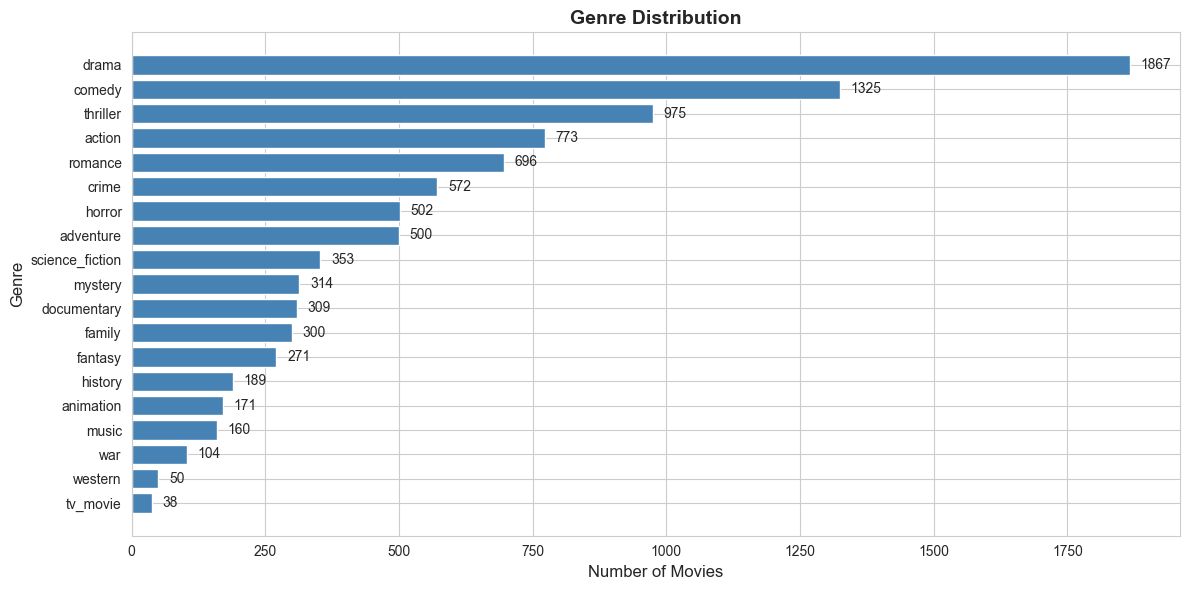

In [9]:
# Visualize genre distribution
fig, ax = plt.subplots(figsize=(12, 6))

genres = list(genre_counts_sorted.keys())
counts = list(genre_counts_sorted.values())

ax.barh(genres, counts, color='steelblue')
ax.set_xlabel('Number of Movies', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
ax.set_title('Genre Distribution', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(counts):
    ax.text(v + 20, i, str(v), va='center')

plt.tight_layout()
plt.show()

## 7. Genre Performance Analysis

In [28]:
# Analyze average gross by genre
print("\nAVERAGE GROSS BY GENRE (Adjusted for Inflation):")
print(f"{'Genre':<20} {'Avg Gross':<20} {'Median Gross':<20} {'Count':<10}")
print("-" * 70)

genre_performance = {}

for genre in genre_columns:
    if genre in df.columns:
        genre_movies = df[df[genre] == 1]
        genre_with_gross = genre_movies[genre_movies['gross_adjusted_2024'].notna()]

        if len(genre_with_gross) > 0:
            avg_gross = genre_with_gross['gross_adjusted_2024'].mean()
            median_gross = genre_with_gross['gross_adjusted_2024'].median()
            count = len(genre_with_gross)
            genre_performance[genre] = avg_gross
            print(f"{genre:<20} ${avg_gross:>15,.0f}  ${median_gross:>15,.0f}  {count:<10}")


AVERAGE GROSS BY GENRE (Adjusted for Inflation):
Genre                Avg Gross            Median Gross         Count     
----------------------------------------------------------------------
action               $        140,431  $         10,845  773       
adventure            $        143,015  $         10,772  500       
animation            $         82,881  $          6,008  171       
comedy               $        131,806  $          8,309  1325      
crime                $        116,566  $         11,153  572       
documentary          $         36,223  $          1,536  309       
drama                $         80,457  $          5,433  1867      
family               $        135,045  $          8,202  300       
fantasy              $        126,279  $          9,779  271       
history              $         61,501  $          5,612  189       
horror               $         95,097  $          6,084  502       
music                $        104,773  $          4,891  

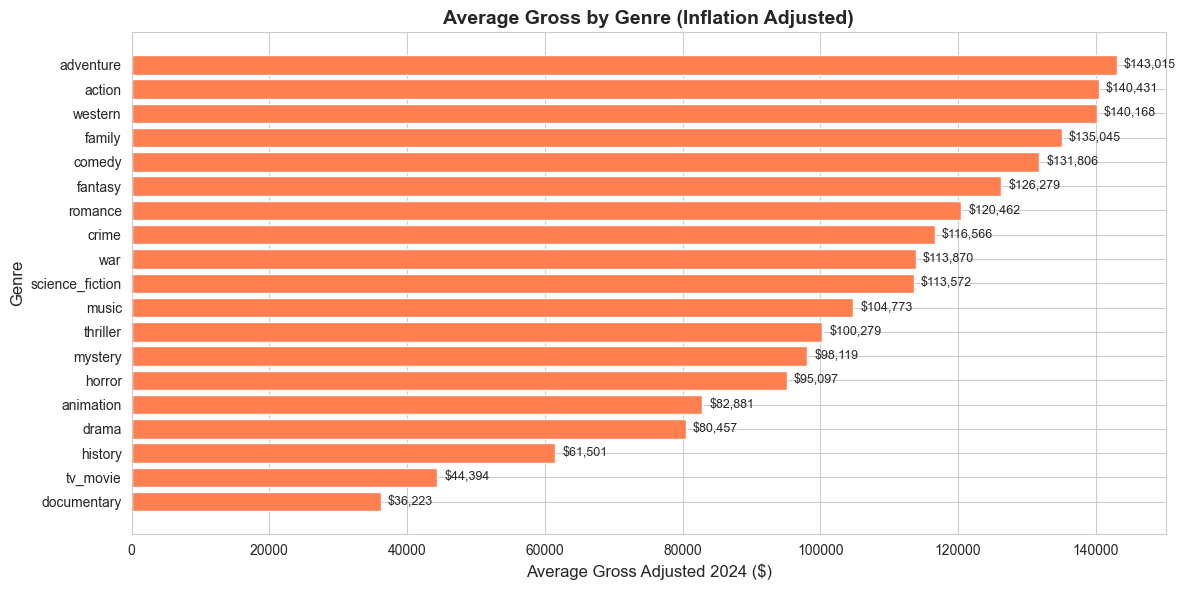

In [29]:
# Visualize genre performance
fig, ax = plt.subplots(figsize=(12, 6))

genre_perf_sorted = dict(sorted(genre_performance.items(), key=lambda x: x[1], reverse=True))
genres_perf = list(genre_perf_sorted.keys())
avg_gross_perf = list(genre_perf_sorted.values())

ax.barh(genres_perf, avg_gross_perf, color='coral')
ax.set_xlabel('Average Gross Adjusted 2024 ($)', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
ax.set_title('Average Gross by Genre (Inflation Adjusted)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(avg_gross_perf):
    ax.text(v + 1000, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Temporal Analysis

In [12]:
# Movies by year
if 'year' in df.columns:
    year_counts = df['year'].value_counts().sort_index()
    print(f"Year range: {df['year'].min()} to {df['year'].max()}")
    print(f"Most movies in a single year: {year_counts.max()} (year {year_counts.idxmax()})")
    print(f"\nTop 5 years by movie count:")
    for year, count in year_counts.nlargest(5).items():
        print(f"  {year}: {count} movies")

Year range: 2000 to 2025
Most movies in a single year: 216 (year 2011)

Top 5 years by movie count:
  2011: 216 movies
  2007: 213 movies
  2006: 206 movies
  2005: 185 movies
  2008: 183 movies


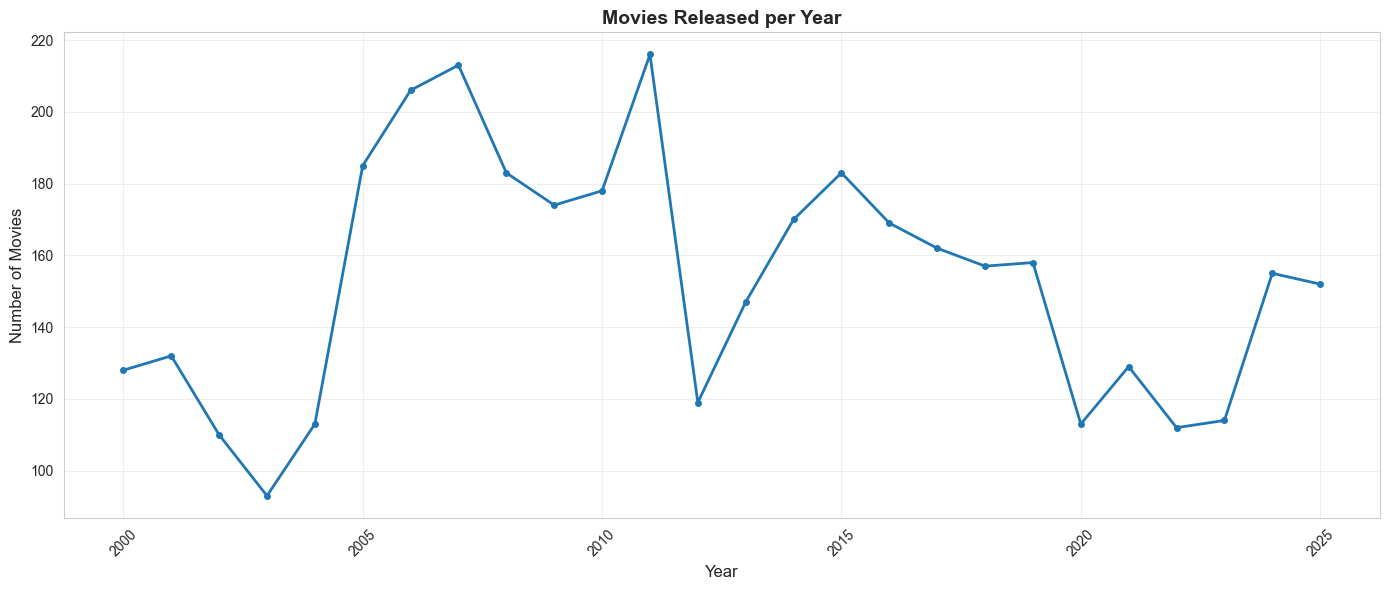

In [13]:
# Visualize movies per year
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(year_counts.index, year_counts.values, marker='o', linewidth=2, markersize=4)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.set_title('Movies Released per Year', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 9. Distributor Analysis

In [14]:
# Top distributors
if 'distributor' in df.columns:
    print("\nTop 10 Distributors by Number of Movies:")
    top_distributors = df['distributor'].value_counts().head(10)
    for dist, count in top_distributors.items():
        pct = count / len(df) * 100
        print(f"  {dist[:40]:<40} {count:>5} ({pct:>5.2f}%)")


Top 10 Distributors by Number of Movies:
  Sony Pictures                              402 (10.12%)
  Warner Bros.                               399 (10.05%)
  Universal                                  344 ( 8.66%)
  20th Century…                              264 ( 6.65%)
  Lionsgate                                  254 ( 6.40%)
  Paramount Pi…                              248 ( 6.25%)
  IFC Films                                  145 ( 3.65%)
  Roadside Att…                              140 ( 3.53%)
  Sony Picture…                              103 ( 2.59%)
  A24                                        102 ( 2.57%)


## 10. Data Quality Assessment

In [15]:
print("\nDATA QUALITY ISSUES:")
print("="*80)

issues = []

# Check for negative values in financial columns
for col in ['gross', 'revenue', 'budget', 'total_gross']:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            issues.append(f"❌ {col} has {neg_count} negative values")

# Check for unrealistic values
if 'per_theater' in df.columns:
    very_high_per_theater = (df['per_theater'] > 100000).sum()
    if very_high_per_theater > 0:
        issues.append(f"⚠️ {very_high_per_theater} records have per_theater > $100,000")

# Check for movies with revenue but no budget
if 'revenue' in df.columns and 'budget' in df.columns:
    revenue_no_budget = ((df['revenue'].notna()) & (df['budget'].isna())).sum()
    if revenue_no_budget > 0:
        issues.append(f"ℹ️ {revenue_no_budget} movies have revenue but no budget data")

if issues:
    print("\nIssues Found:")
    for issue in issues:
        print(f"  {issue}")
else:
    print("\n✅ No major data quality issues found!")


DATA QUALITY ISSUES:

✅ No major data quality issues found!


## 11. Usability Assessment: Gross and Revenue Columns

In [30]:
print("\nUSABILITY ASSESSMENT: GROSS AND REVENUE COLUMNS")
print("="*80)

print("\nGROSS column:")
if 'gross' in df.columns:
    gross_available = df['gross'].notna().sum()
    gross_pct = gross_available / len(df) * 100
    print(f"  ✓ Available in {gross_available:,} records ({gross_pct:.1f}%)")
    print(f"  ✓ Range: ${df['gross'].min():,.0f} to ${df['gross'].max():,.0f}")
    print(f"  ✓ Mean: ${df['gross'].mean():,.0f}")

    if gross_pct > 80:
        print(f"  ✅ HIGHLY USABLE - Good coverage")
    elif gross_pct > 50:
        print(f"  ⚠️ MODERATELY USABLE - Acceptable coverage but some missing data")
    else:
        print(f"  ❌ LIMITED USABILITY - Significant missing data")

print("\nREVENUE column:")
if 'revenue' in df.columns:
    revenue_available = df['revenue'].notna().sum()
    revenue_pct = revenue_available / len(df) * 100
    print(f"  ✓ Available in {revenue_available:,} records ({revenue_pct:.1f}%)")
    print(f"  ✓ Range: ${df['revenue'].min():,.0f} to ${df['revenue'].max():,.0f}")
    print(f"  ✓ Mean: ${df['revenue'].mean():,.0f}")

    if revenue_pct > 80:
        print(f"  ✅ HIGHLY USABLE - Good coverage")
    elif revenue_pct > 50:
        print(f"  ⚠️ MODERATELY USABLE - Acceptable coverage but some missing data")
    else:
        print(f"  ❌ LIMITED USABILITY - Significant missing data")


USABILITY ASSESSMENT: GROSS AND REVENUE COLUMNS

GROSS column:
  ✓ Available in 3,971 records (100.0%)
  ✓ Range: $3 to $12,150,000
  ✓ Mean: $62,860
  ✅ HIGHLY USABLE - Good coverage

REVENUE column:
  ✓ Available in 3,971 records (100.0%)
  ✓ Range: $0 to $2,923,706,026
  ✓ Mean: $71,330,247
  ✅ HIGHLY USABLE - Good coverage


## 12. Top Films

In [17]:
# Sample of highest grossing films
if 'gross_adjusted_2024' in df.columns and 'title' in df.columns and 'year' in df.columns:
    top_films = df.nlargest(20, 'gross_adjusted_2024')[['title', 'year', 'gross_adjusted_2024', 
                                                          'revenue_adjusted_2024', 'genre_names']]
    print("\nTop 20 Highest Grossing Films (Adjusted for Inflation):")
    display(top_films)


Top 20 Highest Grossing Films (Adjusted for Inflation):


,title,year,gross_adjusted_2024,revenue_adjusted_2024,genre_names
3486,The Suicide Squad,2021,1.403821e+07,1.949374e+08,"Action, Comedy, Adventure"
3645,Tom and Jerry,2021,4.621632e+06,0.000000e+00,"Comedy, Western"
3284,The Majestic,2002,3.220136e+06,6.595388e+07,"Drama, Romance"
3901,Wish Upon,2017,2.919290e+06,1.826153e+07,"Horror, Thriller, Fantasy"
3968,Zoolander,2001,2.527329e+06,1.074221e+08,Comedy
2143,Orange County,2002,2.411440e+06,7.533574e+07,"Comedy, Drama"
2081,Not Another Teen Movie,2001,2.394777e+06,1.174737e+08,Comedy
2341,Redline,2007,2.309855e+06,0.000000e+00,"Action, Thriller"
2948,The Chronicles of Riddick,2004,2.307335e+06,1.918309e+08,"Action, Science Fiction"
3695,Twilight,2025,2.251302e+06,5.722343e+08,"Fantasy, Drama, Romance"
